In [5]:
from datetime import datetime, timezone
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from random import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace these with your InfluxDB token, organization, and bucket
org = "ur3e"
bucket = "ur3e"
token = "BkQo1WObUd_cdaOmW3tQfymyGavrrPCmEqPsZwRS3-yTHZzECj5j_6X8MLQRdhbYtTnxKR6rDSi6Wne7g03VBA=="

# Initialize the client
client = InfluxDBClient(url="http://localhost:8086", token=token, org=org)
write_api = client.write_api(write_options=SYNCHRONOUS)   
query_api = client.query_api()

In [6]:
time_start = "-5m"
time_stop = "now()"
window = "1s"

query_sensor_data = f'''
from(bucket: "ur3e")
  |> range(start: {time_start}, stop: {time_stop})
  |> filter(fn: (r) => r["_measurement"] == "sensor_data")
  |> filter(fn: (r) => r["_field"] =~ /(qd|q)_actual_joint_0/)
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

df_sensor_data = query_api.query_data_frame(query_sensor_data)

In [7]:
print(df_sensor_data.head())

    result  table                            _time  \
0  _result      0 2026-04-07 08:12:38.726083+00:00   
1  _result      0 2026-04-07 08:12:38.776401+00:00   
2  _result      0 2026-04-07 08:12:38.827201+00:00   
3  _result      0 2026-04-07 08:12:38.875152+00:00   
4  _result      0 2026-04-07 08:12:38.923814+00:00   

                            _start                            _stop  \
0 2026-04-07 08:09:33.661741+00:00 2026-04-07 08:14:33.661741+00:00   
1 2026-04-07 08:09:33.661741+00:00 2026-04-07 08:14:33.661741+00:00   
2 2026-04-07 08:09:33.661741+00:00 2026-04-07 08:14:33.661741+00:00   
3 2026-04-07 08:09:33.661741+00:00 2026-04-07 08:14:33.661741+00:00   
4 2026-04-07 08:09:33.661741+00:00 2026-04-07 08:14:33.661741+00:00   

  _measurement     source  q_actual_joint_0  qd_actual_joint_0  
0  sensor_data  pt_mockup      7.736163e-09                0.0  
1  sensor_data  pt_mockup     -8.047148e-08                0.0  
2  sensor_data  pt_mockup     -1.647498e-07          

(0, 0)

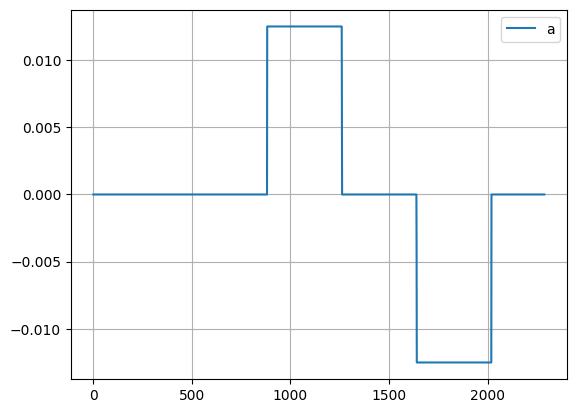

In [10]:
sensor_data_np = df_sensor_data.to_numpy()

qd_actual_joint_0 = sensor_data_np[:, -1]
q_actual_joint_0 = sensor_data_np[:, -2]

# Convert to degrees
def rad2deg(x):
    return 180*x/np.pi
qd_actual_joint_0 = rad2deg(qd_actual_joint_0)
q_actual_joint_0 = rad2deg(q_actual_joint_0)

plt.plot(np.diff(qd_actual_joint_0, 1), '-', label="a")
# plt.plot(qd_actual_joint_0, '-', label="v")
# plt.plot(q_actual_joint_0, '-', label="x")
plt.legend()
plt.grid()


# import matplotlib.ticker as ticker
# ax = plt.gca()
# ax.yaxis.set_major_locator(ticker.MultipleLocator(base=90))
# plt.grid()
len(qd_actual_joint_0[21159:21411]), len(qd_actual_joint_0[25644:25953])

Observationer:
- Mockup accelererer op til max hastighed ($v_{max}$) med $\frac{A_{max}}{20}$
- Mockuppen må kun accelerere i 1/3 af tiden, cruise i 1/3 af tiden og decelerere i 1/3 af tiden.